In [25]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import smarts_cerebellum.globals as gl

df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')

controls = ['CUP_1001', 'CUP_1002', 'JHP_1001', 'JHP_1002', 'JHP_1004']
metric = 'FaMap'
df = df[df.metric == metric]
df = df[~df.subj_id.isin(controls)]

region = ['CST']
regions = [f'{region[0]}_R', f'{region[0]}_L']
df = df[df.Object.isin(regions)]

/localscratch/tmp/ipykernel_7320/1013308861.py:9: DtypeWarning: Columns (2,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')


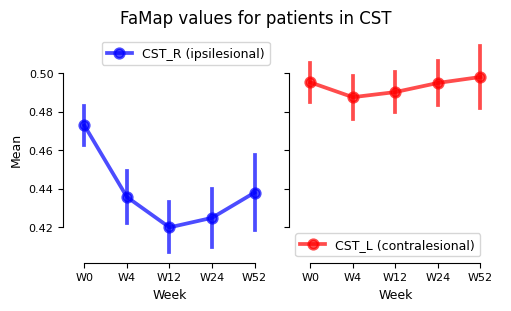

In [34]:
fig, axs = plt.subplots(1,2, figsize = (5,3), sharey = True, constrained_layout = True)
sns.pointplot(x = 'Week', y = 'Mean', data = df[df.Object == regions[0]], alpha = .7, label = f'{regions[0]} (ipsilesional)', color = 'blue', ax = axs[0], errorbar = 'se')
sns.pointplot(x = 'Week', y = 'Mean', data = df[df.Object == regions[1]], alpha = .7, label = f'{regions[1]} (contralesional)', color = 'red', ax = axs[1], errorbar = 'se')

plt.suptitle(f'{metric} values for patients in {region[0]}')
plt.legend()
sns.despine(trim = True)
plt.show()

In [27]:
print(f'---t-test between affected and unaffected {region[0]} patients--- \n')

for week in df.week.unique():
    t_val, p_val = stats.ttest_rel(df[(df.week == week) & (df.Object == f'{region[0]}_R')]['Mean'], df[(df.week == week) & (df.Object == f'{region[0]}_L')]['Mean'])
    print(f'Week {week}: t-value = {t_val}, p-value = {p_val} \n')
    

---t-test between affected and unaffected CST patients--- 

Week 0: t-value = -2.4986076551813325, p-value = 0.026658683483036502 

Week 4: t-value = -6.252947351024849, p-value = 4.174110638649337e-06 

Week 12: t-value = -6.320459010941107, p-value = 7.67850053067061e-06 

Week 24: t-value = -6.353396694433509, p-value = 9.578714860240437e-06 

Week 52: t-value = -5.136782713382094, p-value = 0.00024631355985294543 



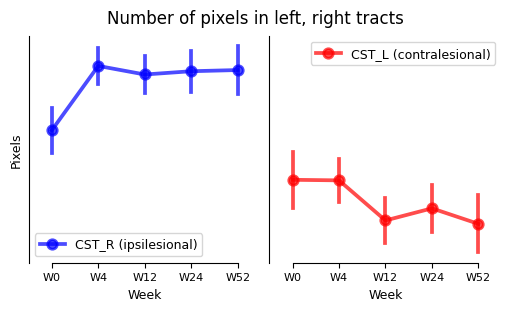

In [32]:
fig, axs = plt.subplots(1,2, figsize = (5,3), sharey = True, constrained_layout = True)
sns.pointplot(x = 'Week', y = 'Pixels', data = df[df.Object == regions[0]], alpha = .7, label = f'{regions[0]} (ipsilesional)', color = 'blue', ax = axs[0], errorbar = 'se')
sns.pointplot(x = 'Week', y = 'Pixels', data = df[df.Object == regions[1]], alpha = .7, label = f'{regions[1]} (contralesional)', color = 'red', ax = axs[1], errorbar = 'se')

plt.suptitle(f'Number of pixels in left, right tracts')
plt.legend()
axs[0].set_yticklabels([])
axs[0].set_yticks([])
sns.despine(trim = True)
plt.show()